# 🌡️ Land Temperature Trends (1850–2015)

Exploratory data analysis and regression modelling of global land surface temperatures using the Berkeley Earth dataset (Berkeley Earth, via Kaggle).

The analysis focuses exclusively on **land surface temperatures** — ocean data were excluded to isolate terrestrial warming trends. Monthly records from 1850 to 2015 are used to explore long-term trends, compare linear and polynomial regression models, and investigate asymmetric warming patterns between daily maximum and minimum temperatures.

## 1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('data/GlobalTemperatures.csv')
data.shape


(3192, 9)

## 2. Data Exploration

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   str    
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), str(1)
memory usage: 224.6 KB


In [4]:
# Drop ocean temperature columns — analysis focuses on land data only
data_land = data.drop(columns = ['LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty'])
data_land

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
3187,2015-08-01,14.755,0.072,20.699,0.110,9.005,0.170
3188,2015-09-01,12.999,0.079,18.845,0.088,7.199,0.229
3189,2015-10-01,10.801,0.102,16.450,0.059,5.232,0.115
3190,2015-11-01,7.433,0.119,12.892,0.093,2.157,0.106


## 3. Data Cleaning

In [5]:
# check for missing values
data_land.isna().sum()

dt                                      0
LandAverageTemperature                 12
LandAverageTemperatureUncertainty      12
LandMaxTemperature                   1200
LandMaxTemperatureUncertainty        1200
LandMinTemperature                   1200
LandMinTemperatureUncertainty        1200
dtype: int64

In [6]:
# drop rows with missing land temperature values
data_land.dropna(subset = ['LandAverageTemperature', 'LandAverageTemperatureUncertainty'], inplace = True)
data_land.head()


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN


In [7]:
#convert date column to datetime
data_land['dt'] = pd.to_datetime(data_land['dt'])
data_land.info()

<class 'pandas.DataFrame'>
Index: 3180 entries, 0 to 3191
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   dt                                 3180 non-null   datetime64[us]
 1   LandAverageTemperature             3180 non-null   float64       
 2   LandAverageTemperatureUncertainty  3180 non-null   float64       
 3   LandMaxTemperature                 1992 non-null   float64       
 4   LandMaxTemperatureUncertainty      1992 non-null   float64       
 5   LandMinTemperature                 1992 non-null   float64       
 6   LandMinTemperatureUncertainty      1992 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 198.8 KB


In [8]:
#summary statistics
data_land.describe()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty
count,3180,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,1883-06-14 11:37:21.509434,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849
min,1750-01-01 00:00:00,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000
25%,1817-03-24 06:00:00,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000
50%,1883-06-16 00:00:00,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000
75%,1949-09-08 12:00:00,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250
max,2015-12-01 00:00:00,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000
std,NaN,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838


In [9]:
# interquartile range - check for outliers
iqr = data_land.quantile(0.75) - data_land.quantile(0.25)
print(iqr)

dt                                   48380 days 06:00:00
LandAverageTemperature                           8.23625
LandAverageTemperatureUncertainty                 1.2325
LandMaxTemperature                                8.2395
LandMaxTemperatureUncertainty                      0.397
LandMinTemperature                               8.11325
LandMinTemperatureUncertainty                    0.30325
dtype: object


## 4. Exploratory Visualization

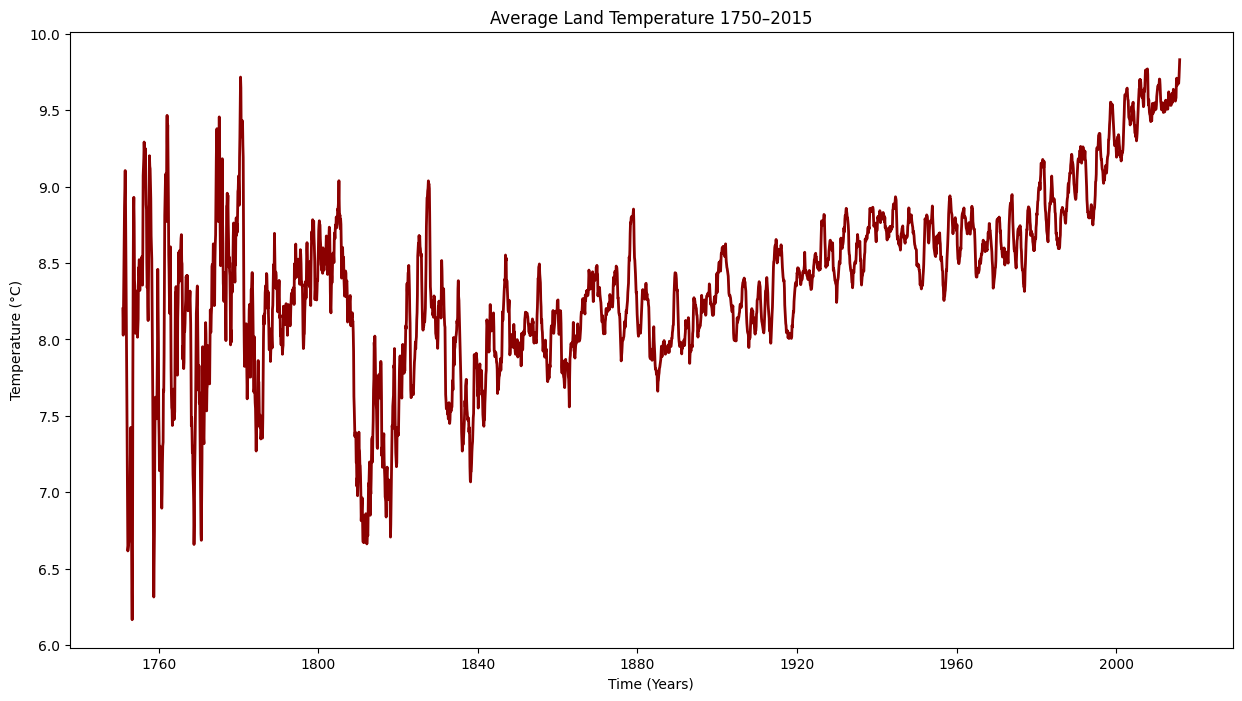

In [10]:
data_land['rolling_12'] = data_land['LandAverageTemperature'].rolling(window=12).mean()

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

sns.lineplot(x=data_land['dt'], y=data_land['rolling_12'], 
             color='darkred', linewidth=2, ax=ax)

ax.set(xlabel='Time (Years)', ylabel='Temperature (°C)',
       title='Average Land Temperature 1750–2015')
plt.show()

In [11]:
# filter to post-1850 data - more consistent and reliable records
data_land_1850 = data_land.dropna()
data_land_1850.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,rolling_12
1200,1850-01-01,0.749,1.105,8.242,1.738,-3.206,2.822,7.885083
1201,1850-02-01,3.071,1.275,9.970,3.007,-2.291,1.623,7.921167
1202,1850-03-01,4.954,0.955,10.347,2.401,-1.905,1.410,7.892167
1203,1850-04-01,7.217,0.665,12.934,1.004,1.018,1.329,7.907917
1204,1850-05-01,10.004,0.617,15.655,2.406,3.811,1.347,7.895000


In [ ]:
# summary statistics for post-1850 data
data_land_1850.describe()


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,rolling_12
count,1992,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,1932-12-16 00:11:33.975904,8.571583,0.276663,14.350601,0.479782,2.743595,0.431849,8.566226
min,1850-01-01 00:00:00,0.404000,0.034000,5.900000,0.044000,-5.407000,0.045000,7.558583
25%,1891-06-23 12:00:00,4.430000,0.099750,10.212000,0.142000,-1.334500,0.155000,8.208167
50%,1932-12-16 12:00:00,8.850500,0.230000,14.760000,0.252000,2.949500,0.279000,8.516875
75%,1974-06-08 12:00:00,12.858500,0.347250,18.451500,0.539000,6.778750,0.458250,8.799625
max,2015-12-01 00:00:00,15.482000,1.492000,21.320000,4.373000,9.715000,3.498000,9.831000
std,NaN,4.263193,0.224030,4.309579,0.583203,4.155835,0.445838,0.467861


In [13]:
# interquartile range for post-1850 data
iqr = data_land_1850.quantile(0.75) - data_land_1850.quantile(0.25)
print(iqr)

dt                                   30300 days 00:00:00
LandAverageTemperature                            8.4285
LandAverageTemperatureUncertainty                 0.2475
LandMaxTemperature                                8.2395
LandMaxTemperatureUncertainty                      0.397
LandMinTemperature                               8.11325
LandMinTemperatureUncertainty                    0.30325
rolling_12                                      0.591458
dtype: object


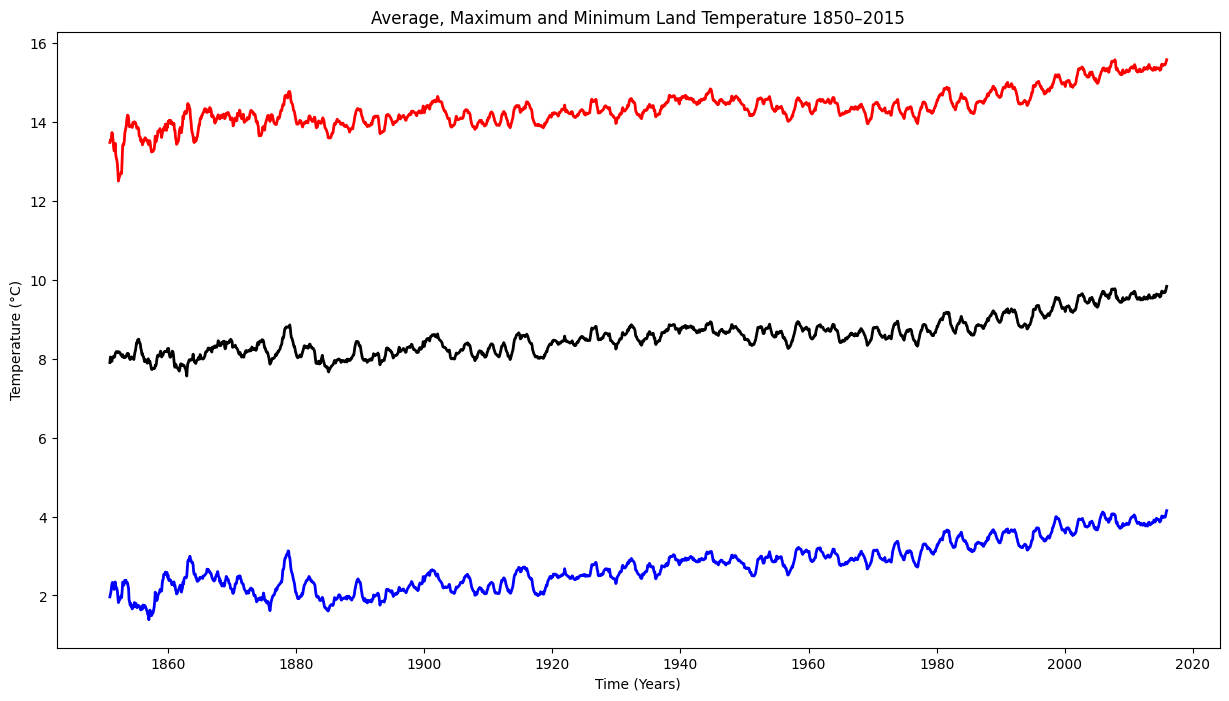

In [14]:
# calculate 12-months rolling mean for average, maximum and minimum temperatures
data_land_1850['rolling_12'] = data_land_1850['LandAverageTemperature'].rolling(window=12).mean()
data_land_1850['rolling_12max'] = data_land_1850['LandMaxTemperature'].rolling(window=12).mean()
data_land_1850['rolling_12min'] = data_land_1850['LandMinTemperature'].rolling(window=12).mean()
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

sns.lineplot(x=data_land_1850['dt'], y=data_land_1850['rolling_12'], 
             color='black', linewidth=2, ax=ax)
sns.lineplot(x=data_land_1850['dt'], y=data_land_1850['rolling_12max'], color = 'red', linewidth=2, ax=ax)
sns.lineplot(x=data_land_1850['dt'], y=data_land_1850['rolling_12min'], color = 'blue', linewidth=2, ax=ax)

ax.set(xlabel='Time (Years)', ylabel='Temperature (°C)',
       title='Average, Maximum and Minimum Land Temperature 1850–2015')
plt.show()

## 5. Regression Analysis

In [ ]:
# first attempt at linear regression - NaN values in rolling mean cause issues
# linear regression on the average temperature data

# change the dt from timestamp to number so I can do my linear regression
x_num = data_land_1850['dt'].map(pd.Timestamp.toordinal)

# linear regression on the Average Temperature on Land
coef = np.polyfit(x_num, data_land_1850['rolling_12'], 1)

#calculate r^2
y_pred = np.poly1d(coef)(x_num)  # predicted values
ss_res = np.sum((data_land_1850['rolling_12'] - y_pred) ** 2)
ss_tot = np.sum((data_land_1850['rolling_12'] - np.mean(data_land_1850['rolling_12'])) ** 2)
r2_lin = 1 - (ss_res / ss_tot)

# print values
print(f"Slope: {coef[0]:.6f} degrees per day")
print(f"R²: {r2_lin:.4f}")

Slope: nan degrees per day
R²: 1.0000


In [16]:
# fix: apply a mask to exclude NaN values before regression
mask = data_land_1850['rolling_12'].notna()
x_clean = x_num[mask]
y_clean = data_land_1850['rolling_12'][mask]

coef = np.polyfit(x_clean, y_clean, 1)
y_pred = np.poly1d(coef)(x_clean)
ss_res = np.sum((y_clean - y_pred) ** 2)
ss_tot = np.sum((y_clean - np.mean(y_clean)) ** 2)
r2_lin = 1 - (ss_res / ss_tot)

# print values
print(f"Slope: {coef[0]:.6f} degrees per day")
print(f"R²: {r2_lin:.4f}")

Slope: 0.000023 degrees per day
R²: 0.7498


**Note:** An R² of 0.75 means that 75% of the temperature variability is explained by the linear trend. The remaining 25% reflects natural variability, climate cycles, and events such as the Krakatoa eruption (1883). However, the result confirms a robust and statistically meaningful warming trend.

In [17]:
# convert slope from degrees per day to degrees per decade

trend_decade = coef[0] * 365 * 10
print(f"Trend: +{trend_decade:.3f} °C per decade")

Trend: +0.085 °C per decade


In [18]:
# Polynomial regression (degree 2) — data suggests a non-linear acceleration in warming

coef_poly = np.polyfit(x_clean, y_clean, 2)
y_pred_poly = np.poly1d(coef_poly)(x_clean)
ss_res_poly = np.sum((y_clean - y_pred_poly) ** 2)
ss_tot_poly = np.sum((y_clean - np.mean(y_clean)) ** 2)
r2_poly = 1 - (ss_res_poly / ss_tot_poly)

# print R^2 value
print(f"R²: {r2_poly:.4f}")


R²: 0.8044


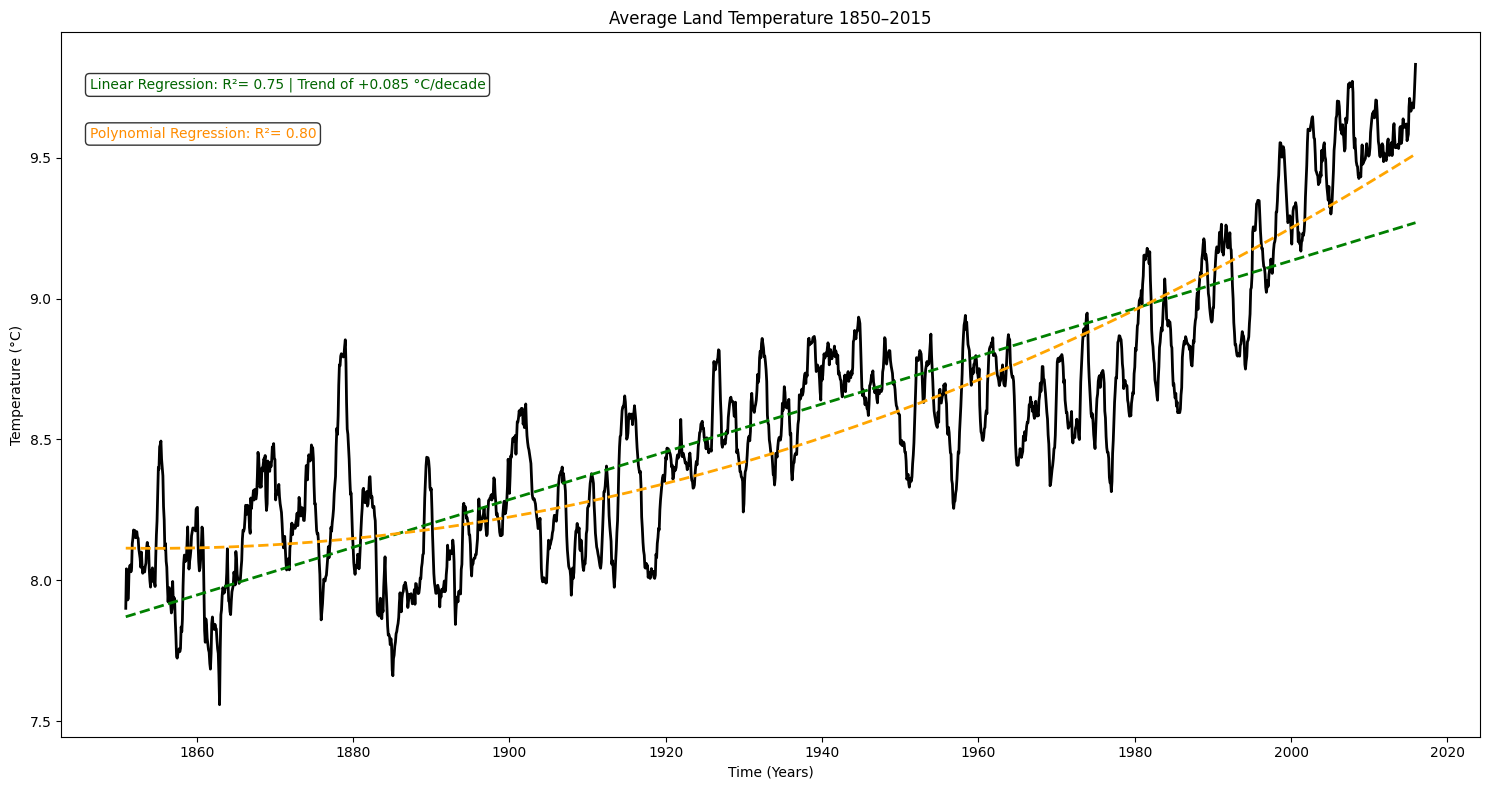

In [19]:
# plotting the linear and polynomial regression with the rolling mean

x_dates = data_land_1850['dt'][mask]

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111)

sns.lineplot(x=x_dates, y=y_clean, 
             color='black', linewidth=2, ax=ax)
sns.lineplot(x=x_dates, y=y_pred, color = 'green',
             linestyle = 'dashed', linewidth=2, ax=ax)
sns.lineplot(x=x_dates, y=y_pred_poly, color = 'orange',
            linestyle = 'dashed', linewidth=2, ax=ax)

ax.annotate(f'Linear Regression: R²= {r2_lin:.2f} | Trend of +{trend_decade:.3f} °C/decade',
            xy=(0.02, 0.92), xycoords='axes fraction',
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.annotate(f'Polynomial Regression: R²= {r2_poly:.2f}',
            xy=(0.02, 0.85), xycoords='axes fraction',
            fontsize=10, color='darkorange',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set(xlabel='Time (Years)', ylabel='Temperature (°C)',
       title='Average Land Temperature 1850–2015')
plt.tight_layout()
plt.show()

## 6. Helper Functions

In [ ]:
# fit a polynomial regression of given degree. Returns coefficients and predicted values

def calculate_regression(x_clean, y_clean, degree):
    coef = np.polyfit(x_clean, y_clean, degree)
    y_pred = np.poly1d(coef)(x_clean)
    return coef, y_pred

In [21]:
coef_poly, y_pred_poly = calculate_regression(x_clean, y_clean, 2)
coef_lin, y_pred_lin = calculate_regression(x_clean, y_clean, 1)

In [22]:
# Calculate the R² (coefficient of determination) between true and predicted values
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

In [23]:
# plot observed temperature data with linear and polynomial regression overlays
def plot_regression(x_dates, y_clean, y_pred_lin, y_pred_poly, r2_lin, r2_poly, trend_decade, title, color):


    fig = plt.figure(figsize=(15,8))
    ax = fig.add_subplot(111)

    sns.lineplot(x=x_dates, y=y_clean, 
             color=color, linewidth=2, ax=ax)
    sns.lineplot(x=x_dates, y=y_pred_lin, color='green',
             linestyle='dashed', linewidth=2, ax=ax)
    sns.lineplot(x=x_dates, y=y_pred_poly, color='orange',
            linestyle='dashed', linewidth=2, ax=ax)

    ax.annotate(f'Linear Regression: R²= {r2_lin:.2f} | Trend of +{trend_decade:.3f} °C/decade',
            xy=(0.02, 0.92), xycoords='axes fraction',
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.annotate(f'Polynomial Regression: R²= {r2_poly:.2f}',
            xy=(0.02, 0.85), xycoords='axes fraction',
            fontsize=10, color='darkorange',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set(xlabel='Time (Years)', ylabel='Temperature (°C)', title=title)
    plt.tight_layout()
    plt.show()
    

In [24]:
# prepare the max values for linear and poly regressions

mask_max = data_land_1850['rolling_12max'].notna()
y_clean_max = data_land_1850['rolling_12max'][mask_max]
x_num_max = data_land_1850['dt'].map(pd.Timestamp.toordinal)[mask_max]
x_dates_max = data_land_1850['dt'][mask_max]
print(len(y_clean_max), len(x_num_max), len(x_dates_max))

1981 1981 1981


In [25]:
# prepare the min values for linear and poly regressions

mask_min = data_land_1850['rolling_12min'].notna()
y_clean_min = data_land_1850['rolling_12min'][mask_min]
x_num_min = data_land_1850['dt'].map(pd.Timestamp.toordinal)[mask_min]
x_dates_min = data_land_1850['dt'][mask_min]
print(len(y_clean_min), len(x_num_min), len(x_dates_min))

1981 1981 1981


In [26]:
coef_lin_max, y_pred_lin_max = calculate_regression(x_num_max, y_clean_max, 1)
coef_poly_max, y_pred_poly_max = calculate_regression(x_num_max, y_clean_max, 2)

In [27]:
coef_lin_min, y_pred_lin_min = calculate_regression(x_num_min, y_clean_min, 1)
coef_poly_min, y_pred_poly_min = calculate_regression(x_num_min, y_clean_min, 2)

In [28]:
r2_lin_max = calculate_r2(y_clean_max, y_pred_lin_max)
r2_poly_max = calculate_r2(y_clean_max, y_pred_poly_max)

r2_lin_min = calculate_r2(y_clean_min, y_pred_lin_min)
r2_poly_min = calculate_r2(y_clean_min, y_pred_poly_min)

print('Max R^2 linear:', r2_lin_max, 'Max R^2 poly:', r2_poly_max,
      'Min R^2 linear:', r2_lin_min, 'Min R^2 poly:', r2_poly_min )

Max R^2 linear: 0.6419700667920121 Max R^2 poly: 0.6693373438617436 Min R^2 linear: 0.8033665433738304 Min R^2 poly: 0.857665893955982


In [ ]:
# convert slopes from degrees per day to degrees per decade
trend_decade_max = coef_lin_max[0] * 365 * 10
trend_decade_min = coef_lin_min[0] * 365 * 10

print(f"Average: +{trend_decade:.3f} °C per decade")
print(f"Max:     +{trend_decade_max:.3f} °C per decade")
print(f"Min:     +{trend_decade_min:.3f} °C per decade")

Average: +0.085 °C per decade
Max:     +0.075 °C per decade
Min:     +0.114 °C per decade


## 7. Results

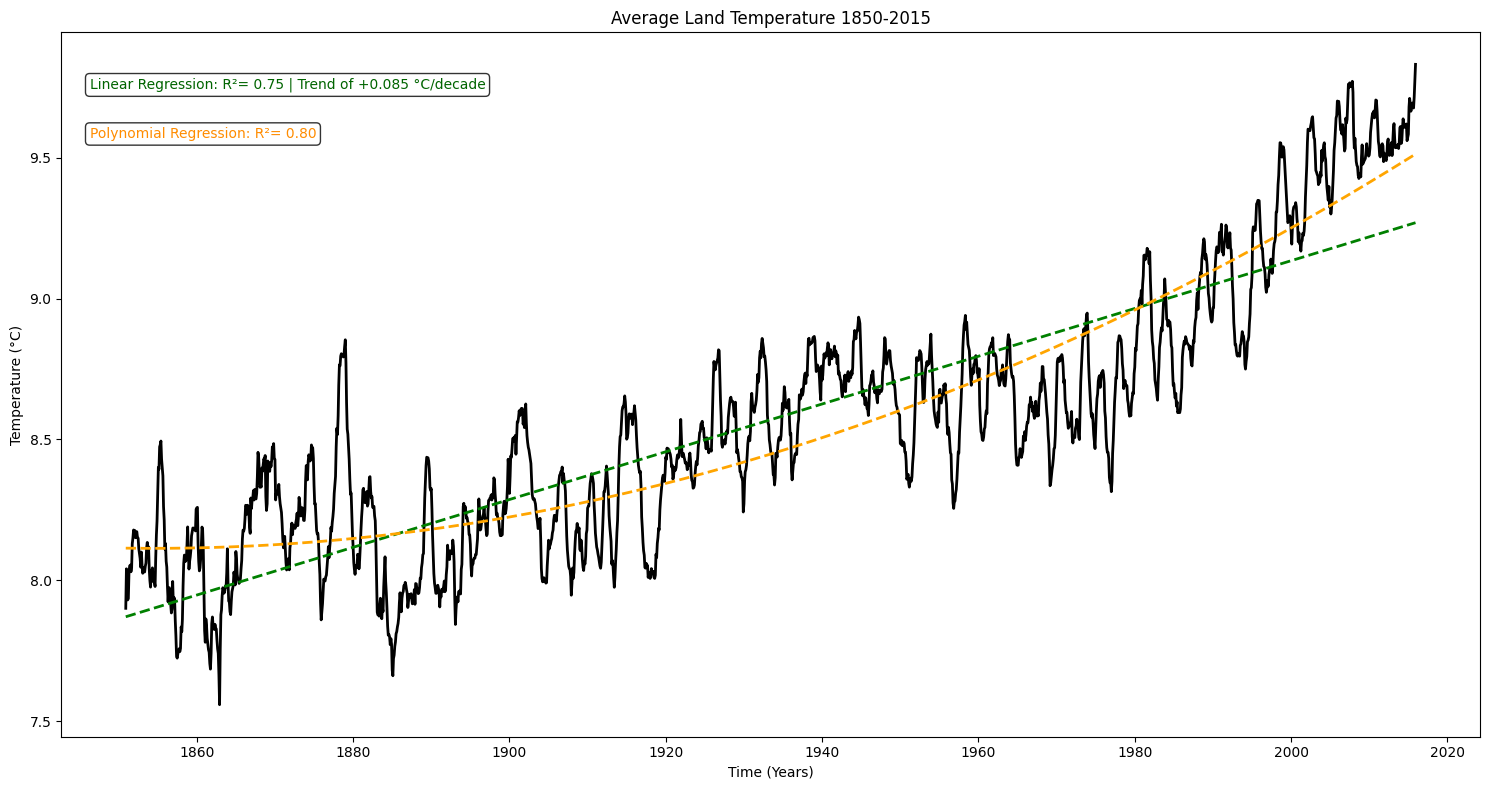

In [30]:
plot_regression(x_dates, y_clean, y_pred_lin, y_pred_poly, r2_lin, r2_poly, trend_decade, 'Average Land Temperature 1850-2015', 'black')

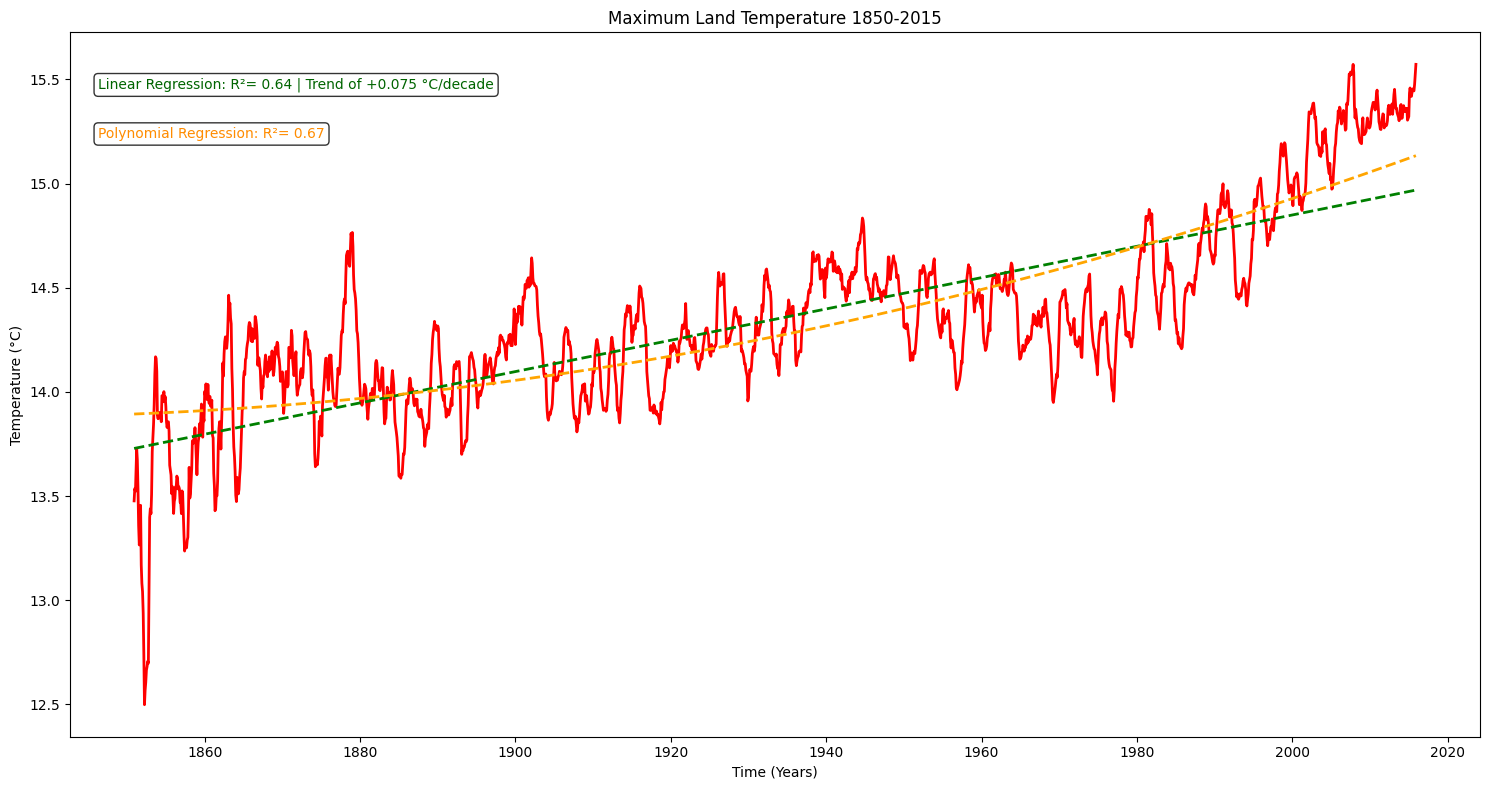

In [31]:
plot_regression(x_dates_max, y_clean_max, y_pred_lin_max, y_pred_poly_max, r2_lin_max, r2_poly_max, trend_decade_max, 'Maximum Land Temperature 1850-2015', 'red')

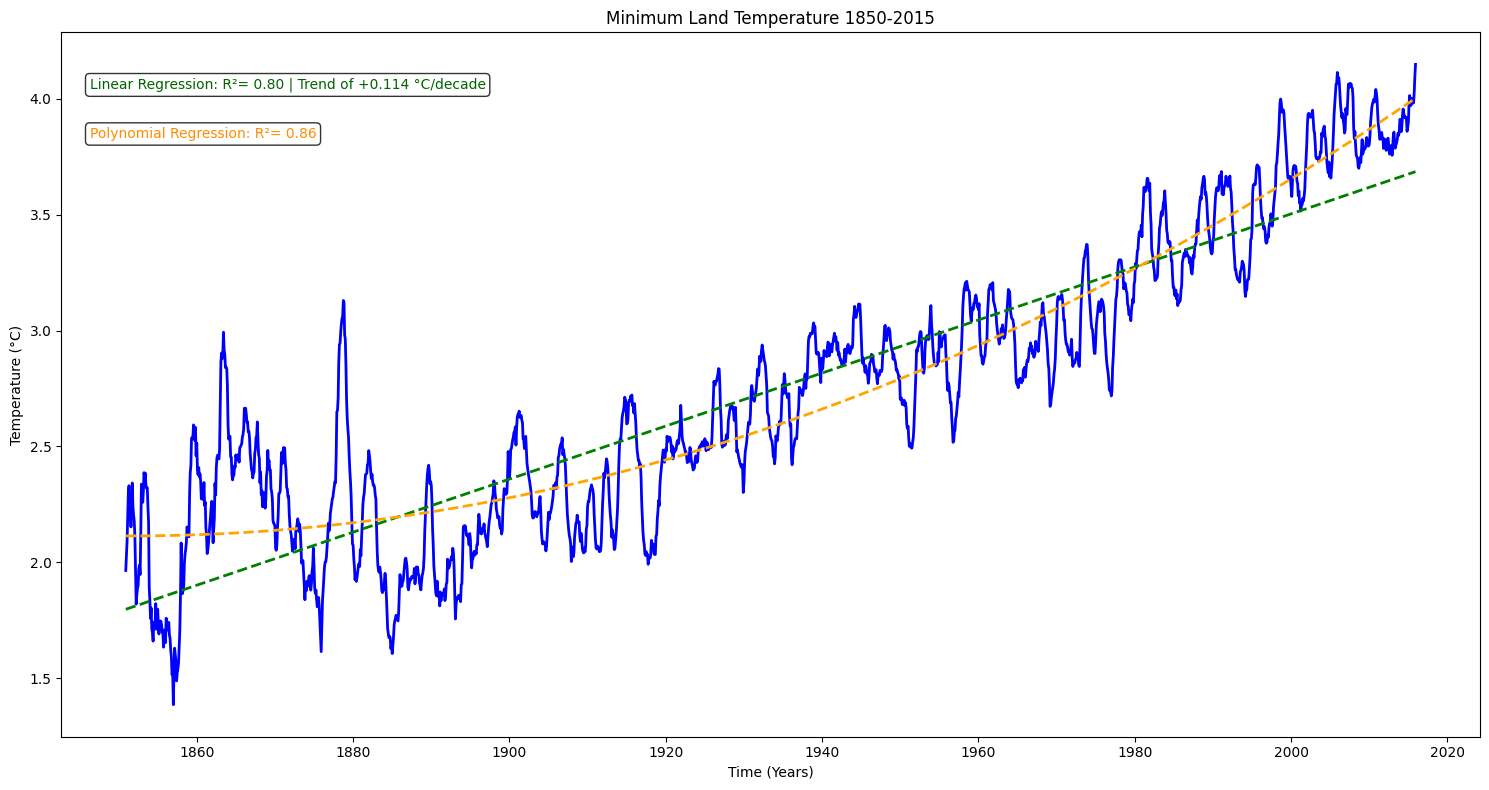

In [32]:
plot_regression(x_dates_min, y_clean_min, y_pred_lin_min, y_pred_poly_min, r2_lin_min, r2_poly_min, trend_decade_min, 'Minimum Land Temperature 1850-2015', 'blue')

In [33]:
# plot regression overlays on a given matplotlib axis — for use in multi-panel figures
def plot_regression_subplots(x_dates, y_clean, y_pred_lin, y_pred_poly, r2_lin, r2_poly, trend_decade, title, color, ax):

    sns.lineplot(x=x_dates, y=y_clean, 
             color=color, linewidth=2, ax=ax)
    sns.lineplot(x=x_dates, y=y_pred_lin, color='green',
             linestyle='dashed', linewidth=2, ax=ax)
    sns.lineplot(x=x_dates, y=y_pred_poly, color='orange',
            linestyle='dashed', linewidth=2, ax=ax)

    ax.annotate(f'Linear Regression: R²= {r2_lin:.2f} | Trend of +{trend_decade:.3f} °C/decade',
            xy=(0.02, 0.92), xycoords='axes fraction',
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.annotate(f'Polynomial Regression: R²= {r2_poly:.2f}',
            xy=(0.02, 0.85), xycoords='axes fraction',
            fontsize=10, color='darkorange',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set(xlabel='Time (Years)', ylabel='Temperature (°C)', title=title)

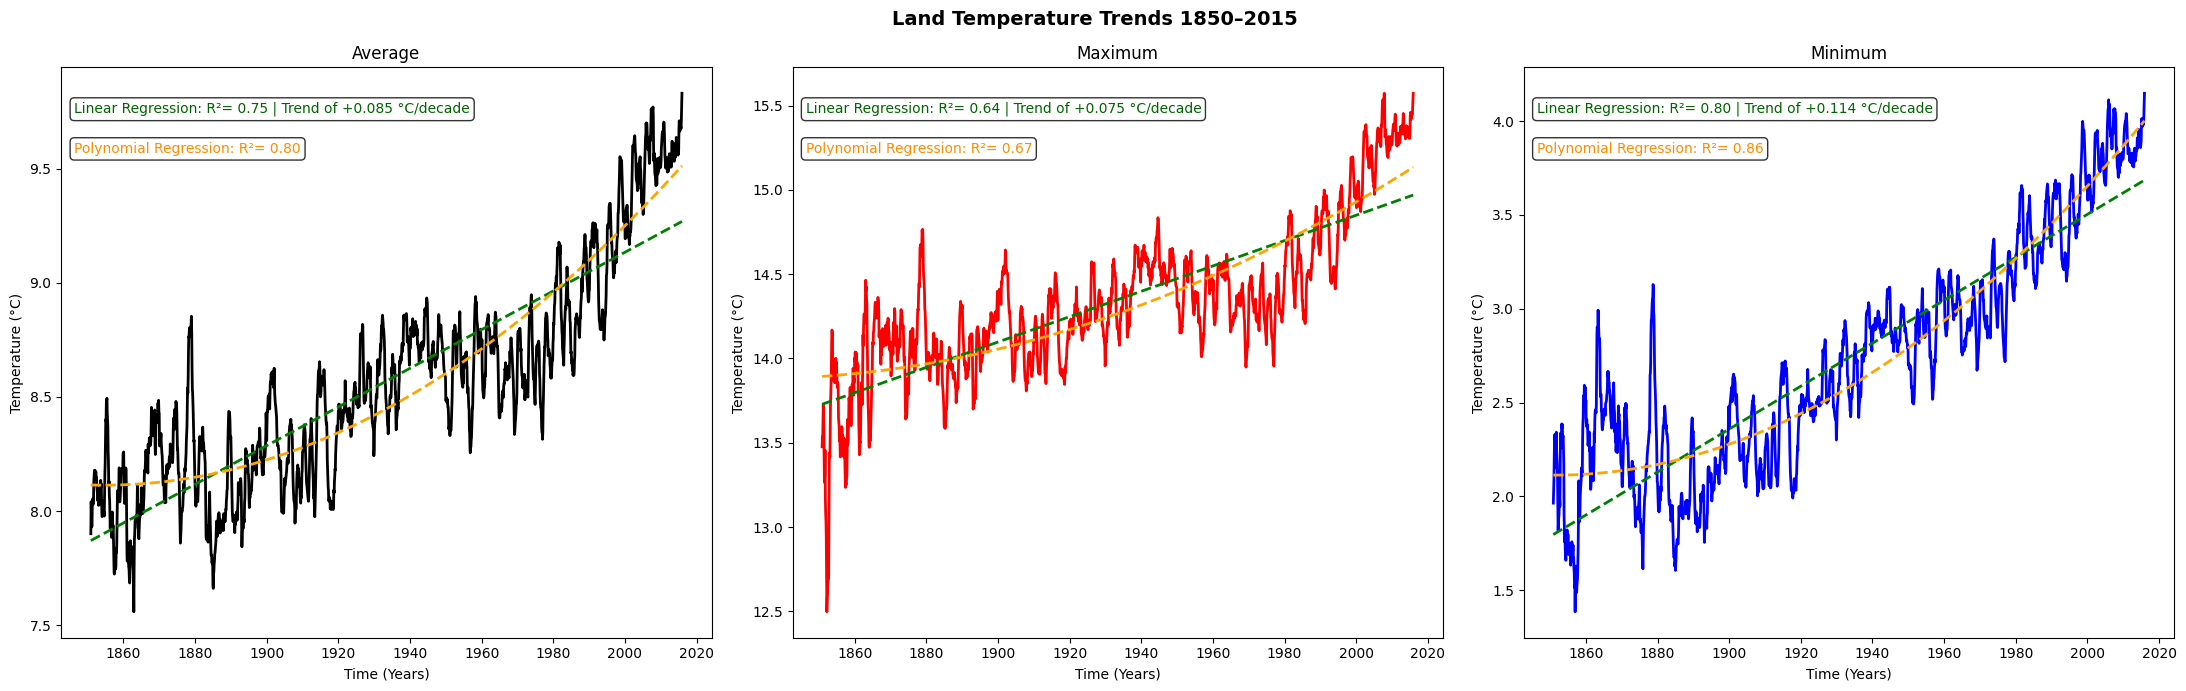

In [34]:
# side-by-side comparison of average, maximum and minimum temperature trends
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

plot_regression_subplots(x_dates, y_clean, y_pred_lin, y_pred_poly, 
                          r2_lin, r2_poly, trend_decade, 
                          'Average', 'black', ax1)

plot_regression_subplots(x_dates_max, y_clean_max, y_pred_lin_max, y_pred_poly_max, 
                          r2_lin_max, r2_poly_max, trend_decade_max, 
                          'Maximum', 'red', ax2)

plot_regression_subplots(x_dates_min, y_clean_min, y_pred_lin_min, y_pred_poly_min, 
                          r2_lin_min, r2_poly_min, trend_decade_min, 
                          'Minimum', 'blue', ax3)

fig.suptitle('Land Temperature Trends 1850–2015', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

*Note: the y-axis scales differ across the three panels, reflecting the absolute temperature ranges of each variable (Maximum ~12–16 °C, Average ~7–10 °C, Minimum ~1–4 °C). Trend comparisons should be based on the numerical values, not on the visual steepness of the curves.*

## Conclusions

This analysis focuses exclusively on land temperature records. 
Ocean data were excluded from the dataset, as the aim was to  isolate terrestrial warming trends.
Land temperatures are known to warm faster than ocean temperatures, which should be kept in mind when comparing these results to global average figures that include both land and sea surface temperatures.

### 1. Why were the data before 1850 excluded?

The data prior to 1850 were significantly more irregular and noisy, with strong fluctuations that likely reflect lower measurement precision and sparse observational coverage during the early 19th century. Instrumental records were not yet standardized, and global monitoring networks were limited.

From around 1850 onward, temperature records become more consistent and systematic, coinciding with the beginning of modern instrumental climatology and improved observational practices. Although some variability persists until about 1890 (including a noticeable peak around 1880), this period already shows greater stability and reliability.

Importantly, the 1880 anomaly is likely not a measurement error but may reflect real climatic variability, potentially associated with major volcanic eruptions such as Krakatoa (1883), which temporarily affected global temperatures. Therefore, removing pre-1850 data was a methodologically motivated decision based on data quality, while retaining all post-1850 observations avoids over-cleaning the dataset.

### 2. Which model fits the data better and why?

The second-degree polynomial regression consistently provides a better fit than the linear regression.

**Linear regression**: R² ranging from 0.64 (Maximum) to 0.80 (Minimum)

**Polynomial regression**: R² ranging from 0.67 (Maximum) to 0.86 (Minimum)

The higher R² indicates that the polynomial model explains a larger proportion of the variance in the temperature data. This suggests that warming is not perfectly linear over time but shows some curvature, likely reflecting acceleration in recent decades.

While the linear model is useful for estimating long-term average trends (°C per decade), the polynomial model better captures the non-linear dynamics of climate change.

### 3. What are the three temperature trends (°C per decade)?

Average temperature: **+0.085 °C per decade**

Maximum temperature: **+0.075 °C per decade**

Minimum temperature: **+0.114 °C per decade**

The most striking result is that minimum temperatures are increasing substantially faster than maximum temperatures.

### 4. What is the most interesting observation among the three variables?

The most interesting observation is the asymmetric warming pattern:

**Minimum temperatures are increasing much faster than maximum temperatures (+0.114 °C vs +0.075 °C per decade)**.

This means that nights are warming more rapidly than days. Since minimum temperatures typically occur at night and maximum temperatures during the day, this asymmetry is a well-documented signature of the greenhouse effect. Greenhouse gases trap outgoing longwave radiation, which is particularly relevant during nighttime, when there is no incoming solar radiation dominating the energy balance.

As expected, the average temperature trend lies between the minimum and maximum trends.

### 5. What does this mean for the real climate?

A 1.5 °C increase may sound small, but the Earth’s climate system operates under an extremely delicate balance. Small average shifts can have disproportionately large consequences.

The asymmetric warming implies:

- Fewer cold nights

- Reduced frost events

- Longer growing seasons

- Shifts in agricultural productivity

- Disruptions in ecosystems and biological cycles

Many species have narrow thermal tolerance ranges. A shift of 1.5 °C can desynchronize ecological timing — for example, plants blooming before pollinators emerge or fish spawning when food availability no longer aligns.

Climate systems also contain feedback loops. For example, ice melt reduces surface albedo (reflectivity), which increases heat absorption, which leads to further melting — a self-reinforcing cycle.

Historically, large temperature increases have been associated with mass extinction events, such as the Permian extinction, which is linked to a 5–10 °C rise over tens of thousands of years. Today, comparable changes are occurring on a much shorter timescale. The rate of change may be as critical as the absolute magnitude.

A useful analogy comes from **chemistry**: small temperature differences can determine whether a reaction proceeds efficiently or fails entirely. Similarly, ecosystems have thresholds and tipping points. A seemingly small shift can push systems beyond recovery limits.